In [ ]:
#pip install pandas
#pip install sweetviz
#pip install seaborn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
RAIZ  = Path.cwd().parent
IVTA = RAIZ / "data" / "IVTA" / "informe__IVTA_Distritos_2020-2024.csv"
ivta_df = pd.read_csv(IVTA, sep=";")
mediaMadrid_ivta = ivta_df["Indice de Vulnerabilidad Territorial Agregado - media ciudad"]
mediaMadrid_Vulnerabilidad_Bienestar = ivta_df["Índice de Vulnerabilidad Bienestar Social e Igualdad - media ciudad"]
ivta_df = ivta_df[["Nombre distrito", "Fecha datos", "Indice de Vulnerabilidad Territorial Agregado", 
                   "Índice de Vulnerabilidad Bienestar Social e Igualdad"]]

#ivta_df = ivta_df[ivta_df["Nombre distrito"].isin(["Centro", "Villaverde", "Tetuán"])]

ivta_df["Indice de Vulnerabilidad Territorial Agregado"] = ivta_df["Indice de Vulnerabilidad Territorial Agregado"].str.replace(",", ".").astype(float)
ivta_df["Índice de Vulnerabilidad Bienestar Social e Igualdad"] = ivta_df["Índice de Vulnerabilidad Bienestar Social e Igualdad"].str.replace(",", ".").astype(float)

ivta_df = ivta_df.rename(columns={
    "Nombre distrito": "Distrito",
    "Fecha datos": "Año",
})
ivta_df = ivta_df[ivta_df["Distrito"] != "Ciudad de Madrid"]

print(ivta_df.to_string())

                Distrito   Año  Indice de Vulnerabilidad Territorial Agregado  Índice de Vulnerabilidad Bienestar Social e Igualdad
0                 Centro  2020                                           5.53                                                  5.98
1             Arganzuela  2020                                           3.84                                                  4.28
2                 Retiro  2020                                           3.85                                                  4.11
3              Salamanca  2020                                           4.24                                                  4.62
4              Chamartín  2020                                           4.27                                                  4.36
5                 Tetuán  2020                                           5.34                                                  4.53
6               Chamberí  2020                                           5.3

In [3]:
precioVivienda = RAIZ / "data" / "precio vivienda" / "Ayuntamiento_vivienda_distrito_m2_2020-2025.csv"
precioVivienda_df = pd.read_csv(precioVivienda, sep=";", skiprows=5, thousands=".", decimal=",")
precioVivienda_df = precioVivienda_df[["Año", "Distrito", "Euros/m2"]]

#precioVivienda_df = precioVivienda_df[precioVivienda_df["Distrito"].isin(["01. Centro", "17. Villaverde", "06. Tetuán"])]
precioVivienda_df = precioVivienda_df[precioVivienda_df["Año"].isin([2020, 2021, 2022, 2023, 2024])]
precioVivienda_df["Año"] = precioVivienda_df["Año"].astype(int)
precioVivienda_df["Distrito"] = precioVivienda_df["Distrito"].str.replace(r"^\d+\.\s*", "", regex=True)

precioVivienda_df = precioVivienda_df[precioVivienda_df["Distrito"] != "Ciudad de Madrid"]

precioVivienda_df = precioVivienda_df.rename(columns={
    "Euros/m2": "Precio vivienda (€/m²)",
})
precioVivienda_df.info()

<class 'pandas.DataFrame'>
Index: 105 entries, 1 to 109
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Año                     105 non-null    int64  
 1   Distrito                105 non-null    str    
 2   Precio vivienda (€/m²)  105 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 3.3 KB


In [4]:
precioAlquiler = RAIZ / "data" / "precio vivienda - alquiler" / "Precios_alquiler_estadísticas_año-distrito.csv"
precioAlquiler_df = pd.read_csv(precioAlquiler, sep=";", skiprows=4)
precioAlquiler_df["Año"] = pd.to_numeric(precioAlquiler_df["Año"], errors="coerce").astype("Int64")

cols_int = ["Número de viviendas en alquiler", "Número de viviendas en alquiler.1", "Número de viviendas en alquiler.2"]

for col in cols_int:
    precioAlquiler_df[col] = precioAlquiler_df[col].str.replace(".", "", regex=False)
    precioAlquiler_df[col] = pd.to_numeric(
        precioAlquiler_df[col].str.replace(",", ".", regex=False),
        errors="coerce"
    )

for col in cols_int:
    precioAlquiler_df[col] = pd.to_numeric(precioAlquiler_df[col], errors="coerce")

precioAlquiler_df = precioAlquiler_df.dropna(subset=cols_int)

precioAlquiler_df[cols_int] = precioAlquiler_df[cols_int].astype(int)

cols_float = ["Renta media vivienda colectiva (€/m2.mes)", "Renta media vivienda unifamiliar (€/m2.mes)"]

for col in cols_float:
    precioAlquiler_df[col] = precioAlquiler_df[col].str.replace(".", "", regex=False)
    precioAlquiler_df[col] = pd.to_numeric(
        precioAlquiler_df[col].str.replace(",", ".", regex=False),
        errors="coerce"
    )

#precioAlquiler_df = precioAlquiler_df[precioAlquiler_df["Distrito"].isin(["01. Centro", "17. Villaverde", "06. Tetuán"])]

precioAlquiler_df = precioAlquiler_df[["Año", "Distrito", "Número de viviendas en alquiler", "Número de viviendas en alquiler.1", "Número de viviendas en alquiler.2",
                                       "Renta media vivienda colectiva (€/m2.mes)", "Renta media vivienda unifamiliar (€/m2.mes)"]]

precioAlquiler_df["Distrito"] = precioAlquiler_df["Distrito"].str.replace(r"^\d+\.\s*", "", regex=True)

precioAlquiler_df = precioAlquiler_df[precioAlquiler_df["Distrito"] != "Ciudad de Madrid"]


precioAlquiler_df = precioAlquiler_df.rename(columns={
    "Número de viviendas en alquiler": "Nº viviendas en alquiler",
    "Número de viviendas en alquiler.1": "Nº viviendas en alquiler colectiva",
    "Número de viviendas en alquiler.2": "Nº viviendas en alquiler unifamiliar",
    "Renta media vivienda colectiva (€/m2.mes)": "Renta vivienda colectiva (€/m².mes)",
    "Renta media vivienda unifamiliar (€/m2.mes)": "Renta vivienda unifamiliar (€/m².mes)",
})

precioAlquiler_df.info()


<class 'pandas.DataFrame'>
Index: 105 entries, 2 to 110
Data columns (total 7 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Año                                    105 non-null    Int64  
 1   Distrito                               105 non-null    str    
 2   Nº viviendas en alquiler               105 non-null    int64  
 3   Nº viviendas en alquiler colectiva     105 non-null    int64  
 4   Nº viviendas en alquiler unifamiliar   105 non-null    int64  
 5   Renta vivienda colectiva (€/m².mes)    105 non-null    float64
 6   Renta vivienda unifamiliar (€/m².mes)  105 non-null    float64
dtypes: Int64(1), float64(2), int64(3), str(1)
memory usage: 6.7 KB


In [5]:
precioAlquiler_meses = RAIZ / "data" / "precio vivienda - alquiler" / "precio_alquiler_distrito_mes.csv"
precioAlquiler_meses_df = pd.read_csv(precioAlquiler_meses, sep=",", skiprows=4)

#precioAlquiler_meses_df = precioAlquiler_meses_df[precioAlquiler_meses_df["Distrito"].isin(["01. Centro", "17. Villaverde", "06. Tetuán"])]

cols_float = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

for col in cols_float:
    precioAlquiler_meses_df[col] = pd.to_numeric(
        precioAlquiler_meses_df[col].str.replace(",", ".", regex=False),
        errors="coerce"
    )


precioAlquiler_meses_df["Precio alquiler €/m² media del año"] = precioAlquiler_meses_df[["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]].mean(axis=1)

precioAlquiler_meses_df = precioAlquiler_meses_df[["Año", "Distrito", "Precio alquiler €/m² media del año"]]

precioAlquiler_meses_df["Año"] = precioAlquiler_meses_df["Año"].astype(int)
precioAlquiler_meses_df["Distrito"] = precioAlquiler_meses_df["Distrito"].str.replace(r"^\d+\.\s*", "", regex=True)
precioAlquiler_meses_df = precioAlquiler_meses_df[precioAlquiler_meses_df["Distrito"] != "Ciudad de Madrid"]

precioAlquiler_meses_df.info()

<class 'pandas.DataFrame'>
Index: 105 entries, 1 to 109
Data columns (total 3 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Año                                 105 non-null    int64  
 1   Distrito                            105 non-null    str    
 2   Precio alquiler €/m² media del año  105 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 3.3 KB


In [92]:
#DESESTIMADO!!

encuestaOcupacion = RAIZ / "data" / "apartamentos turisticos" / "Encuesta ocupación hotelera.csv"
encuestaOcupacion_df = pd.read_csv(encuestaOcupacion, sep=";", skiprows=5)

encuestaOcupacion_df["Año"] = encuestaOcupacion_df["Año"].astype(int)

encuestaOcupacion_df = encuestaOcupacion_df[encuestaOcupacion_df["Año"].isin([2020, 2021, 2022, 2023, 2024])]
encuestaOcupacion_df = encuestaOcupacion_df[["Año", "Número plazas estimadas", "Número apartamentos estimados"]]

cols_float = ["Número plazas estimadas", "Número apartamentos estimados"]

for col in cols_float:
    encuestaOcupacion_df[col] = encuestaOcupacion_df[col].str.replace(".", "", regex=False)
    encuestaOcupacion_df[col] = pd.to_numeric(
        encuestaOcupacion_df[col].str.replace(",", ".", regex=False),
        errors="coerce"
    )

encuestaOcupacion_df.head(30) 

,Año,Número plazas estimadas,Número apartamentos estimados
10,2020,5929.33,2289.75
11,2021,9202.08,3452.17
12,2022,10586.42,3795.58
13,2023,11710.67,4280.00
14,2024,11491.00,4179.67


In [6]:
apartamentosTuristicos = RAIZ / "data" / "apartamentos turisticos" / "apartamentos turísticos_2020-2024_distri_ establecimientos-plazas.csv"
apartamentosTuristicos_df = pd.read_csv(apartamentosTuristicos, sep=";", skiprows=4, thousands=".")

#apartamentosTuristicos_df = apartamentosTuristicos_df[apartamentosTuristicos_df["Distrito"].isin(["01. Centro", "17. Villaverde", "06. Tetuán"])]

apartamentosTuristicos_df = apartamentosTuristicos_df[["Año", "Distrito", "Establecimientos", "Plazas"]]

apartamentosTuristicos_df["Año"] = apartamentosTuristicos_df["Año"].astype(int)
apartamentosTuristicos_df["Establecimientos"] = apartamentosTuristicos_df["Establecimientos"].astype(int)
apartamentosTuristicos_df["Plazas"] = apartamentosTuristicos_df["Plazas"].astype(int)
apartamentosTuristicos_df["Distrito"] = apartamentosTuristicos_df["Distrito"].str.replace(r"^\d+\.\s*", "", regex=True)

apartamentosTuristicos_df = apartamentosTuristicos_df[apartamentosTuristicos_df["Año"].isin([2020, 2021, 2022, 2023, 2024])]


apartamentosTuristicos_df = apartamentosTuristicos_df.rename(columns={
    "Establecimientos": "Establecimientos turisticos",
    "Plazas": "Plazas en sstablecimientos turisticos",
})

apartamentosTuristicos_df = apartamentosTuristicos_df[apartamentosTuristicos_df["Distrito"] != "Ciudad de Madrid"]

apartamentosTuristicos_df.info()


<class 'pandas.DataFrame'>
Index: 105 entries, 1 to 109
Data columns (total 4 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   Año                                    105 non-null    int64
 1   Distrito                               105 non-null    str  
 2   Establecimientos turisticos            105 non-null    int64
 3   Plazas en sstablecimientos turisticos  105 non-null    int64
dtypes: int64(3), str(1)
memory usage: 4.1 KB


In [24]:
poblacion = RAIZ / "data" / "poblacion distrito" / "poblacion-distrito-barrio_2018-2024.csv"
poblacion_df = pd.read_csv(poblacion, sep=";", thousands=".")

poblacion_df["barrio"] = poblacion_df["barrio"].str.strip()
poblacion_df["distrito"] = poblacion_df["distrito"].str.strip()


poblacion_df = poblacion_df[poblacion_df["distrito"] == poblacion_df["barrio"]]
#poblacion_df = poblacion_df[poblacion_df["barrio"].isin(["Centro", "17. Villaverde", "06. Tetuán"])]

poblacion_df["Año"] = poblacion_df["fecha"].str.extract(r"(\d{4})").astype(int)
poblacion_df = poblacion_df[poblacion_df["distrito"] == poblacion_df["barrio"]]

poblacion_df = poblacion_df.rename(columns={
    "distrito": "Distrito",
    "num_personas": "Poblacion"
})
poblacion_df["Distrito"] = poblacion_df["Distrito"].replace("Todos", "Ciudad de Madrid")

poblacion_df = poblacion_df[["Año", "Distrito", "Poblacion"]]
poblacion_df = poblacion_df[poblacion_df["Año"].isin([2020, 2021, 2022, 2023, 2024])]

poblacion_df = poblacion_df[poblacion_df["Distrito"] != "Ciudad de Madrid"]

poblacion_df.info()
#print(poblacion_df.to_string())

<class 'pandas.DataFrame'>
Index: 105 entries, 0 to 632
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Año        105 non-null    int64
 1   Distrito   105 non-null    str  
 2   Poblacion  105 non-null    int64
dtypes: int64(2), str(1)
memory usage: 3.3 KB


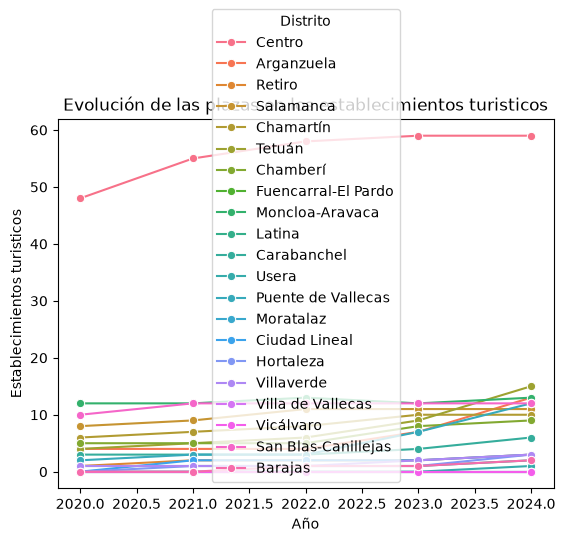

In [8]:
sns.lineplot(
    data=apartamentosTuristicos_df,
    x="Año",
    y="Establecimientos turisticos", #"Plazas en establecimientos turisticos",
    hue="Distrito",
    marker="o"
)

plt.title("Evolución de las plazas en los establecimientos turisticos")
plt.show()

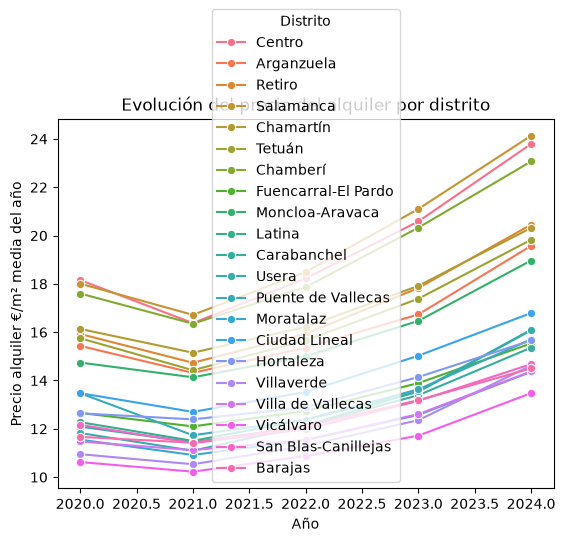

In [9]:
sns.lineplot(
    data=precioAlquiler_meses_df,
    x="Año",
    y="Precio alquiler €/m² media del año",
    hue="Distrito",
    marker="o"
)

plt.title("Evolución del precio del alquiler por distrito")
plt.show()

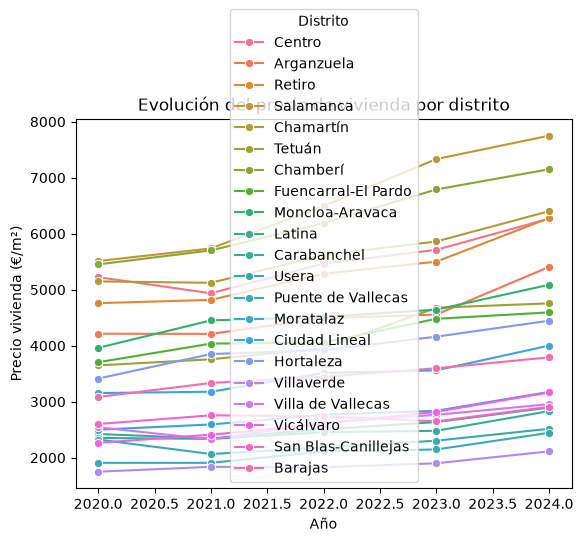

In [10]:
sns.lineplot(
    data=precioVivienda_df,
    x="Año",
    y="Precio vivienda (€/m²)",
    hue="Distrito",
    marker="o"
)

plt.title("Evolución del precio de vivienda por distrito")
plt.show()

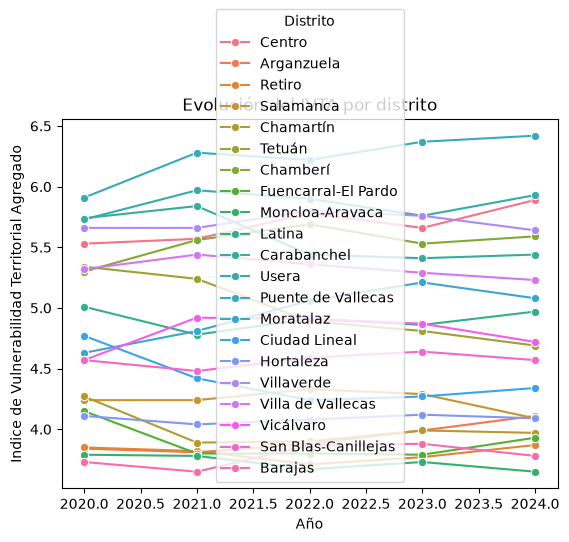

In [11]:
sns.lineplot(
    data=ivta_df,
    x="Año",
    y="Indice de Vulnerabilidad Territorial Agregado",
    hue="Distrito",
    marker="o"
)

plt.title("Evolución del IVTA por distrito")
plt.show()

In [25]:
#apartamentosTuristicos_df, encuestaOcupacion_df, precioAlquiler_df, precioVivienda_df, ivta_df
df_total = (
    apartamentosTuristicos_df
    .merge(precioAlquiler_df, on=["Año", "Distrito"], how="inner")
    .merge(precioVivienda_df, on=["Año", "Distrito"], how="inner")
    .merge(ivta_df, on=["Año", "Distrito"], how="inner")
    .merge(precioAlquiler_meses_df, on=["Año", "Distrito"], how="inner")
    .merge(poblacion_df, on=["Año", "Distrito"], how="inner")
)


#df_total = pd.concat([apartamentosTuristicos_df, precioAlquiler_df, precioVivienda_df, ivta_df], axis=1)

corr = df_total.corr(numeric_only=True)
#print(corr)
df_total.info()

<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 14 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Año                                                   105 non-null    int64  
 1   Distrito                                              105 non-null    str    
 2   Establecimientos turisticos                           105 non-null    int64  
 3   Plazas en sstablecimientos turisticos                 105 non-null    int64  
 4   Nº viviendas en alquiler                              105 non-null    int64  
 5   Nº viviendas en alquiler colectiva                    105 non-null    int64  
 6   Nº viviendas en alquiler unifamiliar                  105 non-null    int64  
 7   Renta vivienda colectiva (€/m².mes)                   105 non-null    float64
 8   Renta vivienda unifamiliar (€/m².mes)                 105 non-null    f

In [ ]:
import sweetviz as sv

reporte = sv.analyze(df_total)
reporte.show_html("reporte_correlaciones_madrid.html")

Feature: Año                                 |▋         | [  7%]   00:00 -> (00:00 left)

findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: Distrito                            |█▎        | [ 13%]   00:00 -> (00:02 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: Establecimientos turisticos         |██        | [ 20%]   00:00 -> (00:02 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal,

Report reporte_correlaciones.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [27]:
variables = [
    "Indice de Vulnerabilidad Territorial Agregado",
    "Índice de Vulnerabilidad Bienestar Social e Igualdad",
    "Precio vivienda (€/m²)",
    "Renta vivienda unifamiliar (€/m².mes)",
    "Renta vivienda colectiva (€/m².mes)",
    "Nº viviendas en alquiler",
    "Establecimientos turisticos",
    "Plazas en sstablecimientos turisticos",
    "Poblacion"
]

corr_pearson = df_total[variables].corr(method="pearson")

print("Pearson")
print(corr_pearson.round(2))

Pearson
                                                    Indice de Vulnerabilidad Territorial Agregado  \
Indice de Vulnerabilidad Territorial Agregado                                                1.00   
Índice de Vulnerabilidad Bienestar Social e Igu...                                           0.71   
Precio vivienda (€/m²)                                                                      -0.42   
Renta vivienda unifamiliar (€/m².mes)                                                       -0.20   
Renta vivienda colectiva (€/m².mes)                                                         -0.35   
Nº viviendas en alquiler                                                                     0.09   
Establecimientos turisticos                                                                  0.18   
Plazas en sstablecimientos turisticos                                                        0.08   
Poblacion                                                                          

In [17]:
corr_spearman = df_total[variables].corr(method="spearman")

print("Spearman")
print(corr_spearman.round(2))

Spearman
                                                    Indice de Vulnerabilidad Territorial Agregado  \
Indice de Vulnerabilidad Territorial Agregado                                                1.00   
Índice de Vulnerabilidad Bienestar Social e Igu...                                           0.67   
Precio vivienda (€/m²)                                                                      -0.51   
Renta vivienda unifamiliar (€/m².mes)                                                       -0.34   
Renta vivienda colectiva (€/m².mes)                                                         -0.42   
Nº viviendas en alquiler                                                                     0.10   
Establecimientos turisticos                                                                 -0.04   
Plazas en sstablecimientos turisticos                                                       -0.02   
num_personas                                                                      

In [177]:
df_total = df_total.sort_values(["Distrito", "Año"])

cols_evolucion = [
    "Establecimientos turisticos",
    "Plazas en sstablecimientos turisticos",
    "Precio vivienda (€/m²)",
    "Precio alquiler €/m² media del año",
    "Indice de Vulnerabilidad Territorial Agregado",
    "Índice de Vulnerabilidad Bienestar Social e Igualdad"
]

for col in cols_evolucion:
    df_total[col + "_var_pct"] = df_total.groupby("Distrito")[col].pct_change() * 100

df_total.head(30)

,Año,Distrito,Establecimientos turisticos,Plazas en sstablecimientos turisticos,Nº viviendas en alquiler,Nº viviendas en alquiler colectiva,Nº viviendas en alquiler unifamiliar,Renta vivienda colectiva (€/m².mes),Renta vivienda unifamiliar (€/m².mes),Precio vivienda (€/m²),Indice de Vulnerabilidad Territorial Agregado,Índice de Vulnerabilidad Bienestar Social e Igualdad,Precio alquiler €/m² media del año,Establecimientos turisticos_var_pct,Plazas en sstablecimientos turisticos_var_pct,Precio vivienda (€/m²)_var_pct,Precio alquiler €/m² media del año_var_pct,Indice de Vulnerabilidad Territorial Agregado_var_pct,Índice de Vulnerabilidad Bienestar Social e Igualdad_var_pct
0,2020,Centro,48,2643,18981,18974,7,15.36,0.00,5223.73,5.53,5.98,18.158333,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,Centro,55,3096,19583,19576,7,15.32,0.00,4935.90,5.57,6.56,16.375000,14.583333,17.139614,-5.510047,-9.821019,0.723327,9.698997
6,2022,Centro,58,3051,19945,19938,7,16.01,0.00,5466.32,5.78,6.61,18.225000,5.454545,-1.453488,10.746166,11.297710,3.770197,0.762195
9,2023,Centro,59,3109,20393,20385,8,16.77,0.00,5712.09,5.66,6.17,20.583333,1.724138,1.901016,4.496078,12.940101,-2.076125,-6.656581
12,2024,Centro,59,3268,20525,20518,7,17.70,0.00,6268.72,5.89,6.45,23.791667,0.000000,5.114185,9.744769,15.587045,4.063604,4.538088
1,2020,Tetuán,4,301,17586,17535,51,13.82,11.44,3648.00,5.34,4.53,15.750000,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,Tetuán,5,327,18140,18082,58,13.95,11.62,3756.93,5.24,4.48,14.425000,25.000000,8.637874,2.986020,-8.412698,-1.872659,-1.103753
7,2022,Tetuán,6,357,18764,18703,61,14.52,12.20,3955.42,4.89,4.09,15.658333,20.000000,9.174312,5.283303,8.549971,-6.679389,-8.705357
10,2023,Tetuán,9,399,19616,19549,67,15.22,12.52,4677.48,4.81,3.86,17.383333,50.000000,11.764706,18.254951,11.016498,-1.635992,-5.623472
13,2024,Tetuán,15,637,20337,20271,66,16.08,13.39,4755.80,4.69,3.78,19.825000,66.666667,59.649123,1.674406,14.046021,-2.494802,-2.072539


In [178]:
resumen = df_total.groupby("Distrito").agg({
    "Establecimientos turisticos": ["first", "last"],
    "Plazas en sstablecimientos turisticos": ["first", "last"],
    "Precio vivienda (€/m²)": ["first", "last"],
    "Precio alquiler €/m² media del año": ["first", "last"],
    "Indice de Vulnerabilidad Territorial Agregado": ["first", "last"],
    "Índice de Vulnerabilidad Bienestar Social e Igualdad": ["first", "last"]
})

print(resumen)

           Establecimientos turisticos       \
                                 first last   
Distrito                                      
Centro                              48   59   
Tetuán                               4   15   
Villaverde                           1    3   

           Plazas en sstablecimientos turisticos       Precio vivienda (€/m²)  \
                                           first  last                  first   
Distrito                                                                        
Centro                                      2643  3268                5223.73   
Tetuán                                       301   637                3648.00   
Villaverde                                     1    28                1749.87   

                    Precio alquiler €/m² media del año             \
               last                              first       last   
Distrito                                                            
Centro      6268.72    

In [179]:
df_2020 = df_total[df_total["Año"] == 2020].set_index("Distrito")
df_2024 = df_total[df_total["Año"] == 2024].set_index("Distrito")

variables = [
    "Establecimientos turisticos",
    "Plazas en sstablecimientos turisticos",
    "Precio vivienda (€/m²)",
    "Precio alquiler €/m² media del año",
    "Indice de Vulnerabilidad Territorial Agregado",
    "Índice de Vulnerabilidad Bienestar Social e Igualdad"
]

variacion_2020_2024 = ((df_2024[variables] - df_2020[variables]) / df_2020[variables]) * 100

print(variacion_2020_2024.round(2))

            Establecimientos turisticos  \
Distrito                                  
Centro                            22.92   
Tetuán                           275.00   
Villaverde                       200.00   

            Plazas en sstablecimientos turisticos  Precio vivienda (€/m²)  \
Distrito                                                                    
Centro                                      23.65                   20.00   
Tetuán                                     111.63                   30.37   
Villaverde                                2700.00                   20.74   

            Precio alquiler €/m² media del año  \
Distrito                                         
Centro                                   31.02   
Tetuán                                   25.87   
Villaverde                               33.49   

            Indice de Vulnerabilidad Territorial Agregado  \
Distrito                                                    
Centro                   

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    data=df_total,
    x="Año",
    y="Precio alquiler €/m² media del año-",
    hue="Distrito",
    marker="o"
)

plt.title("Evolución del precio del alquiler por distrito")
plt.show()

NameError: name 'df_total' is not defined

In [2]:
sns.lineplot(
    data=df_total,
    x="Año",
    y="Precio vivienda (€/m²)-",
    hue="Distrito",
    marker="o"
)

plt.title("Evolución del precio de vivienda por distrito")
plt.show()

NameError: name 'df_total' is not defined

In [3]:
sns.lineplot(
    data=df_total,
    x="Año",
    y="Indice de Vulnerabilidad Territorial Agregado-",
    hue="Distrito",
    marker="o"
)

plt.title("Evolución del IVTA por distrito")
plt.show()

NameError: name 'df_total' is not defined

In [187]:
df_total

,Año,Distrito,Establecimientos turisticos,Plazas en sstablecimientos turisticos,Nº viviendas en alquiler,Nº viviendas en alquiler colectiva,Nº viviendas en alquiler unifamiliar,Renta vivienda colectiva (€/m².mes),Renta vivienda unifamiliar (€/m².mes),Precio vivienda (€/m²),Indice de Vulnerabilidad Territorial Agregado,Índice de Vulnerabilidad Bienestar Social e Igualdad,Precio alquiler €/m² media del año,Establecimientos turisticos_var_pct,Plazas en sstablecimientos turisticos_var_pct,Precio vivienda (€/m²)_var_pct,Precio alquiler €/m² media del año_var_pct,Indice de Vulnerabilidad Territorial Agregado_var_pct,Índice de Vulnerabilidad Bienestar Social e Igualdad_var_pct
0,2020,Centro,48,2643,18981,18974,7,15.36,0.00,5223.73,5.53,5.98,18.158333,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,Centro,55,3096,19583,19576,7,15.32,0.00,4935.90,5.57,6.56,16.375000,14.583333,17.139614,-5.510047,-9.821019,0.723327,9.698997
6,2022,Centro,58,3051,19945,19938,7,16.01,0.00,5466.32,5.78,6.61,18.225000,5.454545,-1.453488,10.746166,11.297710,3.770197,0.762195
9,2023,Centro,59,3109,20393,20385,8,16.77,0.00,5712.09,5.66,6.17,20.583333,1.724138,1.901016,4.496078,12.940101,-2.076125,-6.656581
12,2024,Centro,59,3268,20525,20518,7,17.70,0.00,6268.72,5.89,6.45,23.791667,0.000000,5.114185,9.744769,15.587045,4.063604,4.538088
1,2020,Tetuán,4,301,17586,17535,51,13.82,11.44,3648.00,5.34,4.53,15.750000,NaN,NaN,NaN,NaN,NaN,NaN
4,2021,Tetuán,5,327,18140,18082,58,13.95,11.62,3756.93,5.24,4.48,14.425000,25.000000,8.637874,2.986020,-8.412698,-1.872659,-1.103753
7,2022,Tetuán,6,357,18764,18703,61,14.52,12.20,3955.42,4.89,4.09,15.658333,20.000000,9.174312,5.283303,8.549971,-6.679389,-8.705357
10,2023,Tetuán,9,399,19616,19549,67,15.22,12.52,4677.48,4.81,3.86,17.383333,50.000000,11.764706,18.254951,11.016498,-1.635992,-5.623472
13,2024,Tetuán,15,637,20337,20271,66,16.08,13.39,4755.80,4.69,3.78,19.825000,66.666667,59.649123,1.674406,14.046021,-2.494802,-2.072539


In [186]:
sns.lineplot(
    data=df_total,
    x="Año",
    y="plazas_por_1000_viviendas_alquiler",
    hue="Distrito",
    marker="o"
)

plt.title("Plazas turísticas por cada 1.000 viviendas en alquiler")
plt.show()

ValueError: Could not interpret value `plazas_por_1000_viviendas_alquiler` for `y`. An entry with this name does not appear in `data`.